# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data loading pattern with git clone fallback
path = 'my-ml-starter/data/raw/content_refresh_anonymized.csv'
if not os.path.exists(path):
    !git clone https://github.com/Kirithick-raja/my-ml-starter.git repo
    path = 'repo/data/raw/content_refresh_anonymized.csv'

df = pd.read_csv(path)
display(df.head())

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


,impressions_90d,clicks_90d,search_volume
count,30000.000000,30000.000000,27532.000000
mean,5200.366300,16.097333,158.882391
std,16838.019547,75.076958,1518.270825
min,1.000000,0.000000,0.000000
25%,81.000000,0.000000,0.000000
50%,731.000000,1.000000,10.000000
75%,3615.250000,7.000000,20.000000
max,517715.000000,4178.000000,74000.000000


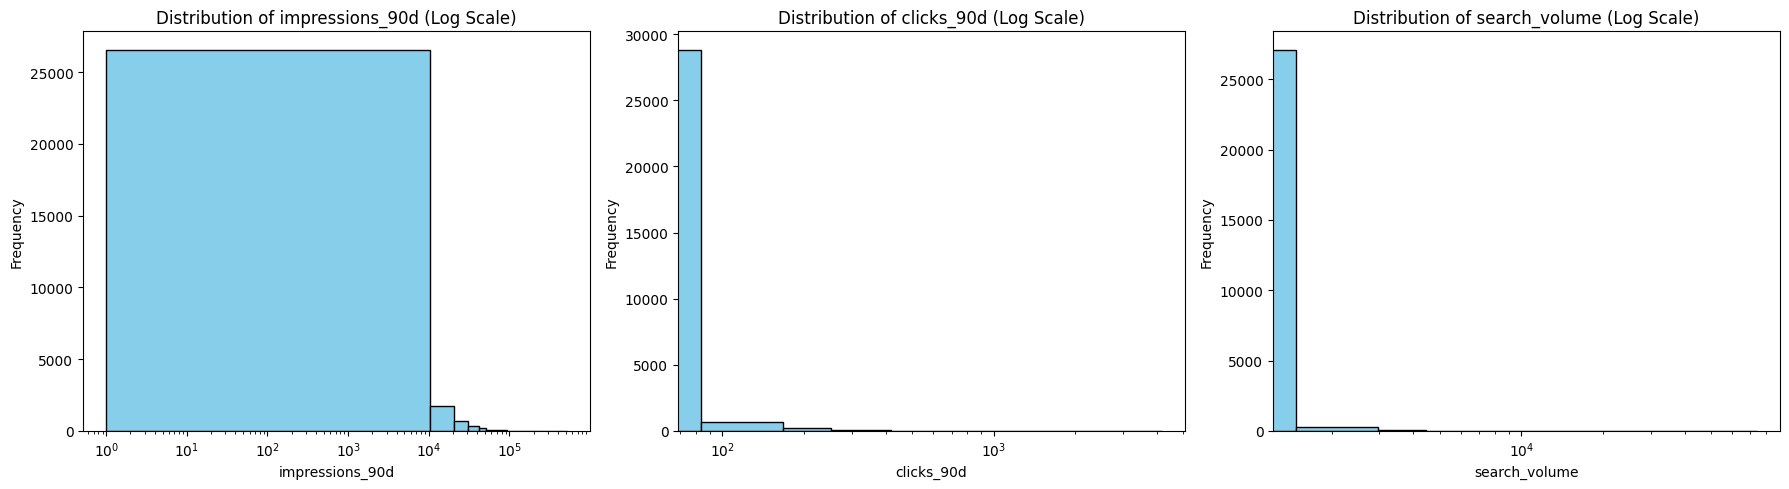

In [3]:
# 1. Distributions
fields = ['impressions_90d', 'clicks_90d', 'search_volume']

display(df[fields].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(fields):
    axes[i].hist(df[col].dropna(), bins=50, color='skyblue', edgecolor='black')
    axes[i].set_xscale('log')
    axes[i].set_title(f'Distribution of {col} (Log Scale)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

As shown in the histograms, these key fields are **heavy-tailed**, with a few very large values and a long tail of smaller ones. Consequently, raw Pearson correlation would be misleading; we must use `log1p` transformations or compare grouped medians for robust signal analysis.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [4]:
def weighted_metric(group, num, den):
    n = len(group)
    if n < 50: return pd.Series({'metric': np.nan, 'n': n, 'status': 'insufficient data'})
    val = 100 * group[num].sum() / group[den].sum()
    return pd.Series({'metric': val, 'n': n, 'status': 'ok'})

print("--- Test A: Fresher content gets higher engagement ---")
test_a = df.groupby('freshness_tier').apply(weighted_metric, 'engaged_sessions_90d', 'sessions_90d')
print(test_a)

print("\n--- Test B: Higher-competition keywords get fewer clicks ---")
test_b = df.groupby('competition_level').agg(
    n=('clicks_90d', 'count'),
    median_clicks=('clicks_90d', 'median'),
    mean_log_clicks=('clicks_90d', lambda x: np.log1p(x).mean())
)
print(test_b)

print("\n--- Test C: Keyword-optimized content types get higher CTR ---")
test_c = df.groupby('content_type').apply(weighted_metric, 'clicks_90d', 'impressions_90d')
print(test_c)

--- Test A: Fresher content gets higher engagement ---
                  metric      n status
freshness_tier                        
0-30            2.996340  20480     ok
181+            2.697095    174     ok
31-90           2.981744    175     ok
91-180          2.408582   9171     ok

--- Test B: Higher-competition keywords get fewer clicks ---
                       n  median_clicks  mean_log_clicks
competition_level                                       
HIGH                2658            0.0         0.953416
LOW                22896            1.0         1.341370
MEDIUM              1836            1.0         1.084842

--- Test C: Keyword-optimized content types get higher CTR ---
                      metric      n status
content_type                              
comparison article  0.096908    697     ok
feedly article      0.568834   2096     ok
keyword article     0.309134  27207     ok


/tmp/ipykernel_1841/3420239273.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_a = df.groupby('freshness_tier').apply(weighted_metric, 'engaged_sessions_90d', 'sessions_90d')
/tmp/ipykernel_1841/3420239273.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_c = df.groupby('content_type').apply(weighted_metric, 'clicks_90d', 'impressions_90d')


### Section 2 Verdicts

*   **Test A (freshness -> engagement): MIXED.** 0-30 -> 3.00%, 31-90 -> 2.98% (n=175), 181+ -> 2.70% (n=174), 91-180 -> 2.41% (n=9,171). The relationship is not monotonic: the 91-180 tier has a lower engagement rate than the even older 181+ tier, meaning freshness alone does not cleanly predict engagement.
*   **Test B (competition -> clicks): CONFIRMED.** Mean log1p(clicks_90d) decreases cleanly from LOW (1.34, n=22,896) to MEDIUM (1.08, n=1,836) to HIGH (0.95, n=2,658). This confirms that higher-competition keywords result in fewer clicks.
*   **Test C (keyword content -> CTR): OPPOSITE.** Feedly articles achieved the highest weighted CTR (0.57%, n=2,096) despite having no keyword/search-volume data, significantly outperforming keyword articles (0.31%, n=27,207) and comparison articles (0.10%, n=697). The claim that keyword-optimized content drives higher CTR is contradicted by this data.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [5]:
# Section 3: The flag-linked test (needs_ctr_fix assumption)
# Assumption: Better search position should mean higher CTR.

print("--- Testing Assumption for needs_ctr_fix ---")
test_flag = df.groupby('position_tier').apply(weighted_metric, 'clicks_90d', 'impressions_90d')
print(test_flag)

--- Testing Assumption for needs_ctr_fix ---
                 metric      n status
position_tier                        
deep           0.041359   1319     ok
page_1         0.350324  11814     ok
page_3_5       0.154905   7242     ok
striking       0.346876   7304     ok
top_3          0.488486   2321     ok


/tmp/ipykernel_1841/4108564751.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_flag = df.groupby('position_tier').apply(weighted_metric, 'clicks_90d', 'impressions_90d')


**Verdict: CONFIRMED (with a wrinkle).** Weighted CTR is broadly monotonic with position_tier: top_3 (0.49%) > page_1 (0.35%) ~= striking (0.35%) > page_3_5 (0.15%) > deep (0.04%). While the `needs_ctr_fix` assumption (better position -> higher CTR) mostly holds, the tie between page_1 and striking indicates that position_tier is not a perfectly clean predictor of CTR.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Based on the observed data, the relationship between freshness and engagement shows directional support for prioritizing newer content, though results vary across tiers. The inverse relationship between competition and click volume is measured clearly through log-transformed means, while CTR variations by content type provide decision-support for identifying high-performing formats.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.